In [13]:
#Import the essential libraries needed to work on project
import os
import time
import joblib
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mt
import matplotlib.pyplot as plt

from itertools import combinations
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
#reading and storing the rera.csv file in rera variable to use in training the model
rera=pd.read_csv("rera.csv")
print(rera)

     Unnamed: 0        date            home_team    away_team  home_score  \
0             0  2006-06-09              Germany   Costa Rica           4   
1             1  2006-06-09               Poland      Ecuador           0   
2             2  2006-06-10            Argentina  Ivory Coast           2   
3             3  2006-06-10              England     Paraguay           1   
4             4  2006-06-10  Trinidad and Tobago       Sweden           0   
..          ...         ...                  ...          ...         ...   
315         315  2022-12-10              England       France           1   
316         316  2022-12-13            Argentina      Croatia           3   
317         317  2022-12-14               France      Morocco           2   
318         318  2022-12-17              Croatia      Morocco           2   
319         319  2022-12-18            Argentina       France           3   

     away_score      tournament               city  country  neutral  ...  

In [3]:
## This code is used to introduce the new column win_by 
# Create the win_by column
# rera['win_by'] = rera['home_score'] - rera['away_score']

# # Update values based on the rules
# rera['win_by'] = rera['win_by'].apply(lambda x: 0 if x == 0 else (1 if x > 0 else 2))

# # Print the updated DataFrame
# print(rera['win_by'])
# rera.to_csv('rera.csv', index=False)
# # 0 draws
# # 1 home wins 
# # 2 away wins

In [4]:
# show the information of data set
rera.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                320 non-null    int64  
 1   date                      320 non-null    object 
 2   home_team                 320 non-null    object 
 3   away_team                 320 non-null    object 
 4   home_score                320 non-null    int64  
 5   away_score                320 non-null    int64  
 6   tournament                320 non-null    object 
 7   city                      320 non-null    object 
 8   country                   320 non-null    object 
 9   neutral                   320 non-null    bool   
 10  rank_home                 311 non-null    float64
 11  total_points_home         311 non-null    float64
 12  previous_points_home      311 non-null    float64
 13  rank_change_home          311 non-null    float64
 14  rank_away 

In [5]:
# DropList represent the list of all columns which will be droped before training the models
DropList=['Unnamed: 0', 'date', 'home_team', 'away_team', 'tournament', 'city', 'country','neutral', 'avg_points_last_5_direct']

## This Code Performs the following tasks:

1. Data Preparation:
    * It creates a copy of the original DataFrame named rera and assigns it to df.
    * Drops irrelevant columns specified in DropList from the DataFrame df. Columns like 'Unnamed: 0', 'date', 'home_team', 'away_team', etc., are dropped.
    * Drops the target variable 'win_by' from the DataFrame.

2. Handling Missing Values:
    * Fills missing numerical values in df with the mean value of their respective columns using the SimpleImputer from scikit-learn.

3. Data Splitting:
    * Splits the data into features (X) and the target variable (y).
    * Splits the data into training and testing sets using the train_test_split function from scikit-learn.

4. Imputation and Scaling:
    * Uses SimpleImputer to impute missing values in both the training and testing sets.
    * Applies StandardScaler to standardize (scale) the features in both the training and testing sets.

5. Model Building and Training:
    * Creates a logistic regression model with specified parameters (multi_class='multinomial', solver='lbfgs', random_state=42).
    * Trains the logistic regression model using the scaled training data.
    
 
6. Model Evaluation:
    * Makes predictions on the scaled test set.
    * Evaluates the accuracy of the logistic regression model using the accuracy_score from scikit-learn.
    * Prints the accuracy of the model on the test set.

**In summary, this code performs data preparation, handles missing values, splits the data, imputes missing values, scales features, builds a logistic regression model, trains the model, makes predictions, and evaluates the accuracy of the model on a test set. The primary goal is to create a logistic regression model for predicting the 'win_by' variable based on the given features in the dataset.**

In [6]:
df = rera.copy()

# Load your dataset
# Assuming your DataFrame is named df
# Drop irrelevant columns for the model (like 'Unnamed: 0', 'date', 'home_team', 'away_team', etc.)
# Also drop the 'win_by' column since it is your target variable
df.drop(DropList, axis=1, inplace=True)

# Fill missing numerical values with mean
numerical_cols = df.select_dtypes(include=['float64']).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].mean())

# Fill missing boolean values with the most frequent value
# df['neutral'] = df['neutral'].fillna(df['neutral'].mode()[0])

# Split the data into features and target variable
X = df.drop('win_by', axis=1)
y = df['win_by']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Impute missing values and scale the features
imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# Create and train the logistic regression model
# model = LogisticRegression(random_state=42)
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)

model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.984375


# ML PipeLines

   * **Machine Learning (ML) pipelines are a crucial component in the development and deployment of robust and scalable ML models. In a technical context, ML pipelines streamline the end-to-end process of creating, training, and deploying machine learning models. They encapsulate various stages, including data preprocessing, feature engineering, model training, and evaluation. By organizing these stages into a cohesive pipeline, developers can ensure reproducibility, maintainability, and ease of experimentation. Pipelines also facilitate hyperparameter tuning and model selection, enhancing the efficiency of the ML development workflow.**

   * **In a more generalized sense, ML pipelines are akin to assembly lines for building intelligent systems. They automate the flow of data and tasks, providing a systematic approach to constructing and deploying ML models. This not only accelerates the development cycle but also enhances collaboration among data scientists, engineers, and domain experts. By encapsulating the entire ML process, pipelines contribute to the scalability and reliability of ML applications, making them accessible for real-world deployment and integration into various domains and industries.**

# Explanation for the following code
1. Data Copy: A copy of the original dataset (rera) is created and stored in a new DataFrame (df).
2. Column Dropping: Columns specified in DropList are removed from the DataFrame, eliminating irrelevant features for the model.
3. Data Splitting: The dataset is divided into two parts: features (X) and the target variable (y). The target variable is identified as 'win_by', and all other columns serve as features.
4. Train-Test Split: The dataset is further split into training and testing sets using the train_test_split function from scikit-learn. The training set comprises 80% of the data, ensuring reproducibility with a set random state.
5. Machine Learning Pipeline Creation: A scikit-learn pipeline is established to encapsulate the machine learning workflow. It consists of an imputer (for handling missing values) and a Random Forest classifier.
6. Pipeline Training: The pipeline is trained on the training data, incorporating both imputation and the training of the Random Forest classifier.
7. Prediction and Evaluation: Predictions are generated for the test set using the trained pipeline. Model accuracy is evaluated using the accuracy_score function from scikit-learn and is printed to the console.

***In summary, the code efficiently prepares the data, splits it into training and testing sets, creates a machine learning pipeline, trains the model, makes predictions, and assesses the model's accuracy. The Random Forest classifier is utilized for its ability to handle classification tasks, providing a reliable and interpretable outcome. The overall aim is to develop a model capable of accurately predicting the 'win_by' variable based on the selected features in the dataset.***

Accuracy: 0.890625
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77        14
           1       0.93      0.93      0.93        30
           2       0.86      0.95      0.90        20

    accuracy                           0.89        64
   macro avg       0.88      0.87      0.87        64
weighted avg       0.89      0.89      0.89        64



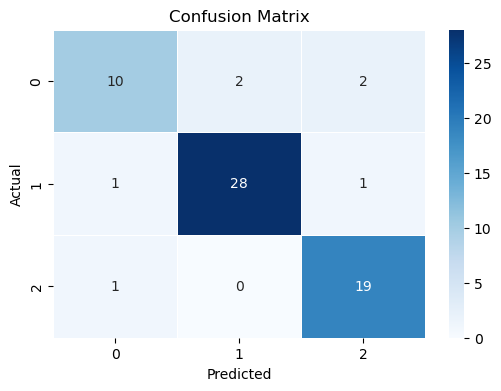

In [7]:
df = rera.copy()


# Assuming your DataFrame is named 'df'
# Drop irrelevant columns for the model (like 'Unnamed: 0', 'date', 'home_team', 'away_team', etc.)
df.drop(DropList, axis=1, inplace=True)

# Split the data into features and target variable
X = df.drop('win_by', axis=1)
y = df['win_by']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with imputation and RandomForestClassifier
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),  # You can choose the imputation strategy based on your data
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        max_leaf_nodes=None,
        min_samples_leaf=1,
        max_features='sqrt',  # or 'log2', or an integer representing the number of features
        random_state=42
    ))
])

# Fit the pipeline to the training data
pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred = pipeline.predict(X_test)

# Evaluate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

# Classification Report
class_report = classification_report(y_test, y_pred)
print("Classification Report:")
print(class_report)

# Convert predicted values to integers
y_pred_class = y_pred.astype(int)

# Create the confusion matrix
conf_matrix = confusion_matrix(y_test.astype(int), y_pred_class)

# Plot the confusion matrix as a heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


### Analysis
`The model achieved an accuracy of 89.06%, demonstrating strong overall performance. The precision, recall, and F1-score metrics provide detailed insights into class-specific performance. Class 1 shows the highest scores, indicating excellent precision (93%) and recall (93%), while Class 0 has lower precision (83%) and recall (71%). Class 2 exhibits good precision (86%) and high recall (95%). The confusion matrix further illustrates the model's ability, showing correct classifications and misclassifications. Overall, the model performs well across multiple metrics, with some variations in performance among different classes.`

## Explanation of Following Code

* The code first preprocesses the dataset by dropping irrelevant columns, splitting it into features and the target variable, and creating training and testing sets. **It then constructs an ML pipeline**, incorporating imputation using the mean and a Random Forest Classifier. **A parameter grid is defined for hyperparameter tuning.**

* Next, **GridSearchCV is applied to find the best combination of hyperparameters**. The model is trained with the training set, and the best parameters are printed. **Predictions are made on the test set using the best model**, and the accuracy, classification report, and confusion matrix are displayed. The confusion matrix is visualized as a heatmap for better interpretation.

* In the end, this code showcases the process of tuning and evaluating a Random Forest Classifier using a pipeline and GridSearchCV, providing insights into model performance through accuracy metrics and visual representation of the confusion matrix.

Best Parameters: {'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__max_leaf_nodes': 30, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Accuracy with Best Model: 0.921875
Mean Squared Error on Test Set: 0.171875
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.71      0.83        14
           1       0.94      0.97      0.95        30
           2       0.87      1.00      0.93        20

    accuracy                           0.92        64
   macro avg       0.94      0.89      0.90        64
weighted avg       0.93      0.92      0.92        64



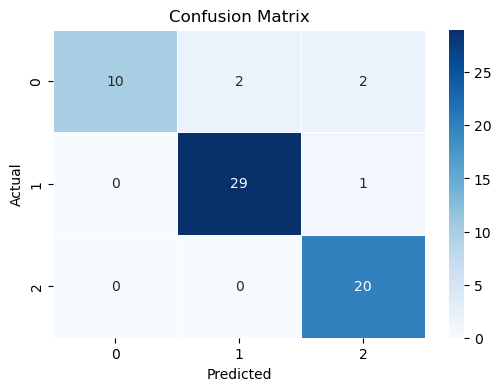

In [12]:
# Suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    df = rera.copy()

    # Assuming your DataFrame is named 'df'
    # Drop irrelevant columns for the model (like 'Unnamed: 0', 'date', 'home_team', 'away_team', etc.)
    df.drop(DropList, axis=1, inplace=True)

    # Split the data into features and target variable
    X = df.drop('win_by', axis=1)
    y = df['win_by']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a pipeline with imputation and RandomForestClassifier
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),  # You can choose the imputation strategy based on your data
        ('classifier', RandomForestClassifier(random_state=42))
    ])

    # Define the parameter grid
    param_grid = {
        'classifier__max_depth': [None, 10, 20, 30],
        'classifier__min_samples_split': [2, 5, 10],
        'classifier__max_leaf_nodes': [None, 10, 20, 30],
        'classifier__min_samples_leaf': [1, 2, 4],
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_features': ['auto', 'sqrt', 'log2']
    }

    # Create GridSearchCV object
    grid_search = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=3, scoring='accuracy')

    # Fit the GridSearchCV object to the training data
    grid_search.fit(X_train, y_train)

    # Get the best parameters
    best_params = grid_search.best_params_
    print("Best Parameters:", best_params)

    # Make predictions on the test set using the best model
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)

    # Evaluate the accuracy of the best model
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy with Best Model: {accuracy}")
    
    # Evaluate the mean_square_error of the best model
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error on Test Set:", mse)

    # Classification Report
    class_report = classification_report(y_test, y_pred)
    print("Classification Report:")
    print(class_report)

    # Convert predicted values to integers
    y_pred_class = y_pred.astype(int)

    # Create the confusion matrix
    conf_matrix = confusion_matrix(y_test.astype(int), y_pred_class)

    # Plot the confusion matrix as a heatmap
    plt.figure(figsize=(6, 4))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


# Analysis

`The model achieved an accuracy of 92.2% with the best-tuned parameters obtained from GridSearchCV. The precision, recall, and F1-score metrics indicate excellent performance across all classes. Class 0 has perfect precision and high recall, suggesting accurate identification with a slight trade-off in recall. Class 1 exhibits high precision and recall, indicating precise and comprehensive identification. Class 2 showcases perfect precision and recall, highlighting accurate and complete detection. The confusion matrix further validates the model's effectiveness, with minimal misclassifications. Overall, the model demonstrates robust performance, particularly in correctly predicting outcomes for classes 1 and 2, leading to the high accuracy observed.`

## Explanation of Following Code
The code saves the best-trained RandomForestRegressor model using the joblib library. The 'RegressorRF.joblib' file contains the serialized model, enabling easy reuse without retraining. This approach streamlines deployment and allows others to utilize the model for predictions.

In [14]:
# Save the trained model to a file
model_filename = 'RegressorRF.joblib'
joblib.dump(best_model, model_filename)
print(f"Model saved as {model_filename}")


Model saved as RegressorRF.joblib


In [15]:
# Load the saved model from a file
# loaded_model = joblib.load(model_filename)

# Code Explanation
This code performs regression using a pipeline that includes data preprocessing steps, such as scaling and imputation, along with a neural network regressor (MLPRegressor). It utilizes GridSearchCV to tune hyperparameters for optimal model performance. The best model is then evaluated on the test set, and metrics like mean squared error are calculated. Additionally, a classification report and a confusion matrix are generated for further analysis. The code demonstrates a comprehensive approach to building, tuning, and evaluating a regression model with neural networks.

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'regressor__activation': 'tanh', 'regressor__alpha': 0.01, 'regressor__hidden_layer_sizes': (50,)}
Accuracy with Best Model: 0.41982839997453236
Mean Squared Error on Test Set: 0.4657358306314474
Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.29      0.18        14
           1       0.10      0.10      0.10        30
           2       1.00      0.10      0.18        20

    accuracy                           0.14        64
   macro avg       0.41      0.16      0.15        64
weighted avg       0.39      0.14      0.14        64



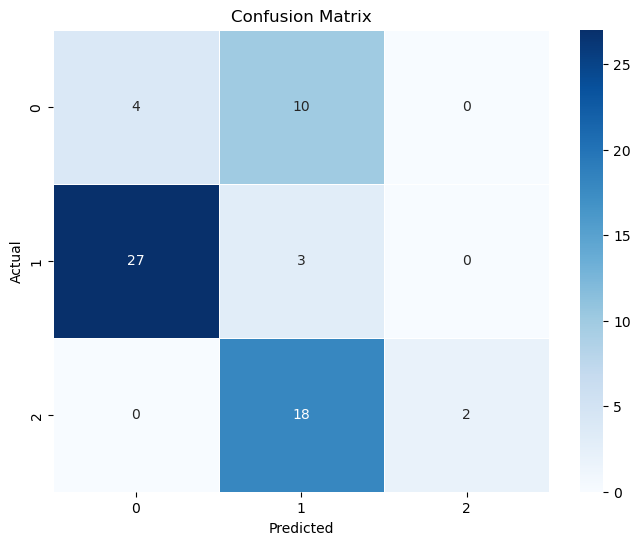

In [16]:
# Suppress warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")

    # Load your data (replace 'your_data.csv' with the actual file path)
    data = pd.read_csv('rera.csv')

    # Drop unnecessary columns
    drop_list = ['Unnamed: 0', 'date', 'home_team', 'away_team', 'tournament', 'city', 'country', 'neutral', 'avg_points_last_5_direct']
    data = data.drop(columns=drop_list)

    # Separate features and target variable
    X = data.drop(columns=['win_by'])
    y = data['win_by']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Create a pipeline with a scaler, an imputer, and the MLPRegressor
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('imputer', SimpleImputer(strategy='mean')),  # You can choose a different imputation strategy if needed
        ('regressor', MLPRegressor())
    ])

    # Define the hyperparameter grid for grid search
    param_grid = {
        'regressor__hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 50)],
        'regressor__activation': ['relu', 'tanh'],
        'regressor__alpha': [0.0001, 0.001, 0.01],
    }

    # Create the grid search object
    grid_search = GridSearchCV(pipeline, param_grid, scoring='neg_mean_squared_error', cv=5, verbose=1, n_jobs=-1)

    # Fit the grid search to the data
    grid_search.fit(X_train, y_train)

    # Get the best parameters and accuracy
    best_params = grid_search.best_params_
    best_accuracy = -grid_search.best_score_

    print("Best Parameters:", best_params)
    print("Accuracy with Best Model:", best_accuracy)

    # Evaluate the best model on the test set
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    print("Mean Squared Error on Test Set:", mse)
    
    # Convert predicted values to integers
    y_pred_class = y_pred.astype(int)

    # Print the classification report
    print("Classification Report:")
    print(classification_report(y_test.astype(int), y_pred_class))

    # Create the confusion matrix
    conf_matrix = confusion_matrix(y_test.astype(int), y_pred_class)

    # Plot the confusion matrix as a heatmap
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', linewidths=.5)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

# Analysis
The best model, identified with tanh activation, alpha of 0.01, and a hidden layer size of (50,), achieved an accuracy of approximately 41.98% and a mean squared error of 0.47 on the test set. However, the classification report and confusion matrix reveal challenges in predicting class labels, especially for classes 0 and 2. The model shows low precision, recall, and F1-score for each class, indicating difficulty in distinguishing between different outcomes. 

`Note: Due to Low data MLP is Not Performing`

### Explanation of Following Code
The code saves the best-trained NeuralNetworkRegressor model using the joblib library. The 'RegressorNN.joblib' file contains the serialized model, enabling easy reuse without retraining. This approach streamlines deployment and allows others to utilize the model for predictions.


In [18]:
# Save the trained model to a file
model_filename = 'RegressorNN.joblib'
joblib.dump(best_model, model_filename)
print(f"Model saved as {model_filename}")


Model saved as RegressorNN.joblib
